# Silent Struggle Clustering Analysis

Notebook ini dibuat sebagai analisis lanjutan dari project **mental health mahasiswa**.

Fokus notebook ini bukan untuk menggantikan model klasifikasi `risk`, tetapi untuk menemukan pola kelompok mahasiswa melalui pendekatan **unsupervised learning / clustering**.

## Tujuan utama

1. Menguji apakah data mahasiswa dapat dikelompokkan menjadi beberapa persona.
2. Membandingkan hasil cluster dengan label `risk`: `Low Risk`, `Medium Risk`, dan `High Risk`.
3. Menjadikan clustering sebagai pendukung insight dan rancangan solusi, terutama untuk **Silent Struggle Dashboard**.

## Catatan penting

Label `risk` pada notebook ini **bukan diagnosis medis**. Label tersebut hanya digunakan sebagai indikator prioritas intervensi berbasis data survei.

## 1. Import Library

Library yang digunakan dibuat sesederhana mungkin agar notebook mudah dijalankan ulang.

In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Load Dataset

Dataset yang digunakan adalah data survei kesehatan mental mahasiswa.

Notebook ini akan mencari file dengan nama `Student Mental health.csv`. Jika dijalankan di environment ChatGPT, path `/mnt/data/Student Mental health.csv` juga disiapkan.

In [4]:
DATA_PATH = Path("Student Mental health.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("./dataset/Student Mental health.csv")

df_raw = pd.read_csv(DATA_PATH)

print("Shape dataset:", df_raw.shape)
df_raw.head()

Shape dataset: (101, 11)


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


## 3. Data Cleaning dan Feature Engineering

Pada tahap ini, data dibersihkan agar lebih konsisten.

Langkah yang dilakukan:

- Rename kolom menjadi lebih sederhana.
- Parsing timestamp.
- Membersihkan format teks.
- Mengubah jawaban `Yes/No` menjadi angka `1/0`.
- Membuat fitur turunan:
  - `issue_count`
  - `has_any_issue`
  - `multiple_issue`
  - `support_status`
  - `risk`

Kolom `risk` dibuat sebagai label prioritas intervensi:

| Risk | Kondisi | Makna |
|---|---|---|
| Low Risk | Tidak ada indikasi, atau sudah mencari bantuan | Tidak menjadi prioritas utama |
| Medium Risk | Ada 1 indikasi dan belum mencari bantuan | Perlu edukasi dan self-assessment |
| High Risk | Ada minimal 2 indikasi dan belum mencari bantuan | Perlu prioritas outreach |

In [5]:
def clean_student_mental_health_data(path):
    raw = pd.read_csv(path)
    df = raw.copy()

    rename_map = {
        "Timestamp": "timestamp",
        "Choose your gender": "gender",
        "Age": "age",
        "What is your course?": "course",
        "Your current year of Study": "year",
        "What is your CGPA?": "cgpa",
        "Marital status": "marital_status",
        "Do you have Depression?": "depression",
        "Do you have Anxiety?": "anxiety",
        "Do you have Panic attack?": "panic_attack",
        "Did you seek any specialist for a treatment?": "treatment"
    }

    df = df.rename(columns=rename_map)

    # Parsing timestamp yang lebih aman untuk format tanggal campuran.
    try:
        df["timestamp"] = pd.to_datetime(
            df["timestamp"],
            errors="coerce",
            dayfirst=True,
            format="mixed"
        )
    except TypeError:
        df["timestamp"] = pd.to_datetime(
            df["timestamp"],
            errors="coerce",
            dayfirst=True
        )

    # Standardisasi teks.
    text_cols = [
        "gender", "course", "year", "cgpa", "marital_status",
        "depression", "anxiety", "panic_attack", "treatment"
    ]

    for col in text_cols:
        df[col] = df[col].astype(str).str.strip()

    # Konversi Yes/No ke 1/0.
    binary_cols = ["marital_status", "depression", "anxiety", "panic_attack", "treatment"]
    yes_no_map = {"Yes": 1, "No": 0, "yes": 1, "no": 0}

    for col in binary_cols:
        df[col] = df[col].map(yes_no_map).astype("Int64")

    # Age dibuat numerik, missing value diisi median.
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df["age"] = df["age"].fillna(df["age"].median()).astype(int)

    # Normalisasi tahun studi.
    df["year"] = (
        df["year"]
        .str.lower()
        .str.replace("year", "", regex=False)
        .str.strip()
        .replace({
            "1": "Year 1",
            "2": "Year 2",
            "3": "Year 3",
            "4": "Year 4"
        })
    )

    # Normalisasi course secara ringan.
    df["course"] = (
        df["course"]
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.title()
        .replace({
            "Bit": "BIT",
            "It": "IT",
            "Bcs": "BCS",
            "Koe": "KOE",
            "Benl": "BENL",
            "Irkhs": "IRKHS",
            "Mathemathics": "Mathematics"
        })
    )

    # Normalisasi format CGPA.
    df["cgpa"] = (
        df["cgpa"]
        .str.replace(" ", "", regex=False)
        .str.replace("3.50-4.00", "3.50 - 4.00", regex=False)
        .str.replace("3.00-3.49", "3.00 - 3.49", regex=False)
        .str.replace("2.50-2.99", "2.50 - 2.99", regex=False)
        .str.replace("2.00-2.49", "2.00 - 2.49", regex=False)
        .str.replace("0-1.99", "0 - 1.99", regex=False)
    )

    # Feature engineering mental health.
    mental_cols = ["depression", "anxiety", "panic_attack"]

    df["issue_count"] = df[mental_cols].sum(axis=1).astype(int)
    df["has_any_issue"] = (df["issue_count"] > 0).astype(int)
    df["multiple_issue"] = (df["issue_count"] >= 2).astype(int)

    def assign_support_status(row):
        if row["has_any_issue"] == 1 and row["treatment"] == 0:
            return "Silent Struggle"
        elif row["has_any_issue"] == 1 and row["treatment"] == 1:
            return "Reached Support"
        else:
            return "No Reported Issue"

    df["support_status"] = df.apply(assign_support_status, axis=1)

    def assign_risk(row):
        if row["issue_count"] >= 2 and row["treatment"] == 0:
            return "High Risk"
        elif row["issue_count"] == 1 and row["treatment"] == 0:
            return "Medium Risk"
        else:
            return "Low Risk"

    df["risk"] = df.apply(assign_risk, axis=1)

    risk_order = pd.CategoricalDtype(
        ["Low Risk", "Medium Risk", "High Risk"],
        ordered=True
    )
    df["risk"] = df["risk"].astype(risk_order)

    return df


df = clean_student_mental_health_data(DATA_PATH)

print("Shape setelah cleaning:", df.shape)
df.head()

Shape setelah cleaning: (101, 16)


,timestamp,gender,age,course,year,cgpa,marital_status,depression,anxiety,panic_attack,treatment,issue_count,has_any_issue,multiple_issue,support_status,risk
0,2020-07-08 12:02:00,Female,18,Engineering,Year 1,3.00 - 3.49,0,1,0,1,0,2,1,1,Silent Struggle,High Risk
1,2020-07-08 12:04:00,Male,21,Islamic Education,Year 2,3.00 - 3.49,0,0,1,0,0,1,1,0,Silent Struggle,Medium Risk
2,2020-07-08 12:05:00,Male,19,BIT,Year 1,3.00 - 3.49,0,1,1,1,0,3,1,1,Silent Struggle,High Risk
3,2020-07-08 12:06:00,Female,22,Laws,Year 3,3.00 - 3.49,1,1,0,0,0,1,1,0,Silent Struggle,Medium Risk
4,2020-07-08 12:13:00,Male,23,Mathematics,Year 4,3.00 - 3.49,0,0,0,0,0,0,0,0,No Reported Issue,Low Risk


## 4. Ringkasan KPI Awal

Sebelum masuk ke clustering, kita cek ulang KPI utama.

KPI ini penting karena menjadi alasan kenapa label `risk` dibuat dan kenapa clustering dibutuhkan sebagai analisis tambahan.

In [6]:
total_students = len(df)
at_risk_students = int(df["has_any_issue"].sum())
silent_struggle_students = int(((df["has_any_issue"] == 1) & (df["treatment"] == 0)).sum())
reached_support_students = int(((df["has_any_issue"] == 1) & (df["treatment"] == 1)).sum())
multiple_issue_students = int(df["multiple_issue"].sum())

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Respondents",
        "At-Risk Students",
        "Silent Struggle Students",
        "Reached Support Students",
        "Multiple Indicator Students",
        "At-Risk Rate",
        "Silent Struggle Rate among At-Risk",
        "Support Reach Rate among At-Risk"
    ],
    "Value": [
        total_students,
        at_risk_students,
        silent_struggle_students,
        reached_support_students,
        multiple_issue_students,
        f"{at_risk_students / total_students * 100:.1f}%",
        f"{silent_struggle_students / at_risk_students * 100:.1f}%" if at_risk_students > 0 else "0.0%",
        f"{reached_support_students / at_risk_students * 100:.1f}%" if at_risk_students > 0 else "0.0%"
    ]
})

kpi_summary

,KPI,Value
0,Total Respondents,101
1,At-Risk Students,64
2,Silent Struggle Students,58
3,Reached Support Students,6
4,Multiple Indicator Students,28
5,At-Risk Rate,63.4%
6,Silent Struggle Rate among At-Risk,90.6%
7,Support Reach Rate among At-Risk,9.4%


In [7]:
risk_dist = (
    df["risk"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
    .reset_index()
)

risk_dist.columns = ["risk", "total_students"]
risk_dist["percentage"] = risk_dist["total_students"] / len(df) * 100

risk_dist

,risk,total_students,percentage
0,Low Risk,43,42.574257
1,Medium Risk,36,35.643564
2,High Risk,22,21.782178


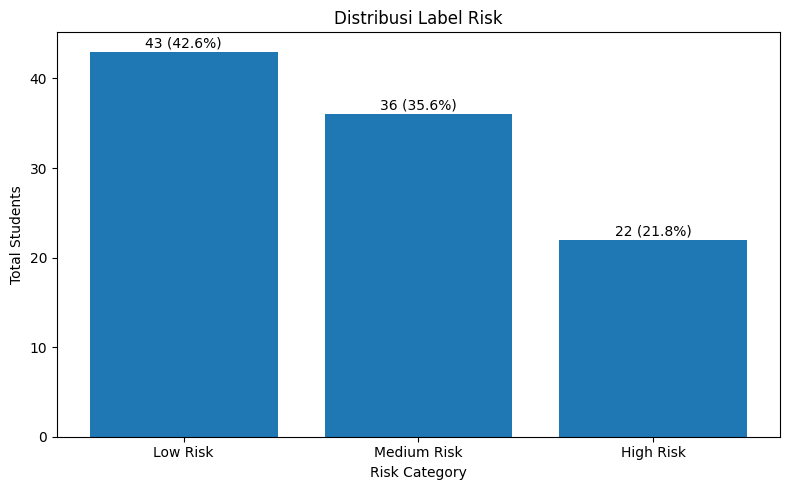

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(risk_dist["risk"], risk_dist["total_students"])
plt.title("Distribusi Label Risk")
plt.xlabel("Risk Category")
plt.ylabel("Total Students")

for i, row in risk_dist.iterrows():
    plt.text(
        i,
        row["total_students"] + 0.5,
        f"{row['total_students']} ({row['percentage']:.1f}%)",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Interpretasi KPI

Dari KPI awal, masalah utama bukan hanya banyaknya mahasiswa yang melaporkan gejala seperti depression, anxiety, atau panic attack.

Masalah yang lebih penting adalah **support gap**, yaitu kondisi ketika mahasiswa sudah memiliki indikasi masalah mental health tetapi belum mencari bantuan profesional.

Karena itu, kolom `risk` dibuat untuk mengubah temuan analisis menjadi prioritas tindakan:

- `Low Risk`: tidak menjadi prioritas utama.
- `Medium Risk`: perlu edukasi dan self-assessment.
- `High Risk`: perlu pendekatan lebih proaktif dari layanan kampus.

Setelah label prioritas terbentuk, clustering digunakan untuk melihat apakah ada pola kelompok mahasiswa yang bisa dijadikan persona intervensi.

## 5. Helper Function untuk Clustering

Bagian ini berisi fungsi pembantu agar eksperimen clustering lebih rapi.

Metrik yang digunakan:

| Metrik | Interpretasi |
|---|---|
| Silhouette Score | Semakin tinggi semakin baik |
| Davies-Bouldin Index | Semakin rendah semakin baik |
| Calinski-Harabasz Score | Semakin tinggi semakin baik |
| Inertia | Semakin rendah semakin baik, biasanya dipakai untuk elbow method |

Namun untuk dataset kecil seperti ini, pemilihan jumlah cluster tidak boleh hanya berdasarkan metrik. Interpretasi cluster juga harus masuk akal.

In [9]:
def to_dense(X):
    if hasattr(X, "toarray"):
        return X.toarray()
    return X


def make_ohe():
    # Kompatibel untuk beberapa versi scikit-learn.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def evaluate_kmeans(X_processed, k_range=range(2, 7), random_state=42):
    X_dense = to_dense(X_processed)
    rows = []

    for k in k_range:
        model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = model.fit_predict(X_dense)

        rows.append({
            "k": k,
            "silhouette_score": silhouette_score(X_dense, labels),
            "davies_bouldin_index": davies_bouldin_score(X_dense, labels),
            "calinski_harabasz_score": calinski_harabasz_score(X_dense, labels),
            "inertia": model.inertia_
        })

    return pd.DataFrame(rows)


def plot_clustering_metrics(eval_df, title_prefix):
    metrics = [
        ("silhouette_score", "Silhouette Score"),
        ("davies_bouldin_index", "Davies-Bouldin Index"),
        ("calinski_harabasz_score", "Calinski-Harabasz Score"),
        ("inertia", "Inertia / Elbow")
    ]

    for metric, label in metrics:
        plt.figure(figsize=(7, 4))
        plt.plot(eval_df["k"], eval_df[metric], marker="o")
        plt.title(f"{title_prefix}: {label}")
        plt.xlabel("Number of Clusters (k)")
        plt.ylabel(label)
        plt.xticks(eval_df["k"])
        plt.tight_layout()
        plt.show()


def plot_pca_clusters(X_processed, labels, title):
    X_dense = to_dense(X_processed)

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_dense)

    plot_df = pd.DataFrame({
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "cluster": labels
    })

    plt.figure(figsize=(8, 6))

    for cluster_id in sorted(plot_df["cluster"].unique()):
        subset = plot_df[plot_df["cluster"] == cluster_id]
        plt.scatter(
            subset["PC1"],
            subset["PC2"],
            label=f"Cluster {cluster_id}",
            alpha=0.8
        )

    plt.title(title)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(
        "Total variance explained by PC1 + PC2:",
        f"{pca.explained_variance_ratio_.sum() * 100:.1f}%"
    )

# Eksperimen A — Clustering Berdasarkan Kondisi Mental Health

Eksperimen pertama menggunakan fitur yang langsung menggambarkan kondisi mental health dan pencarian bantuan:

- `depression`
- `anxiety`
- `panic_attack`
- `treatment`
- `issue_count`

Tujuannya adalah membentuk **persona kondisi**, misalnya:

- mahasiswa stabil,
- mahasiswa dengan satu indikasi,
- mahasiswa dengan beberapa indikasi,
- mahasiswa yang sudah mencari bantuan.

Eksperimen ini cocok untuk insight dan storytelling, tetapi tidak cocok disebut sebagai model prediksi karena fitur yang digunakan sangat dekat dengan label `risk`.

In [10]:
condition_features = [
    "depression",
    "anxiety",
    "panic_attack",
    "treatment",
    "issue_count"
]

X_condition = df[condition_features].copy()

scaler_condition = StandardScaler()
X_condition_processed = scaler_condition.fit_transform(X_condition)

condition_eval = evaluate_kmeans(X_condition_processed, k_range=range(2, 7))

condition_eval

,k,silhouette_score,davies_bouldin_index,calinski_harabasz_score,inertia
0,2,0.482435,1.122560,64.141599,306.451576
1,3,0.504711,0.839456,63.895638,219.184731
2,4,0.538267,0.769245,68.511648,161.915180
3,5,0.661813,0.653021,88.869860,107.380305
4,6,0.788408,0.551293,128.591760,65.010404


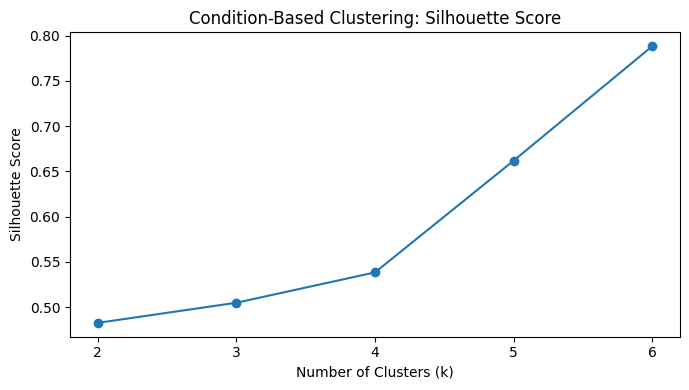

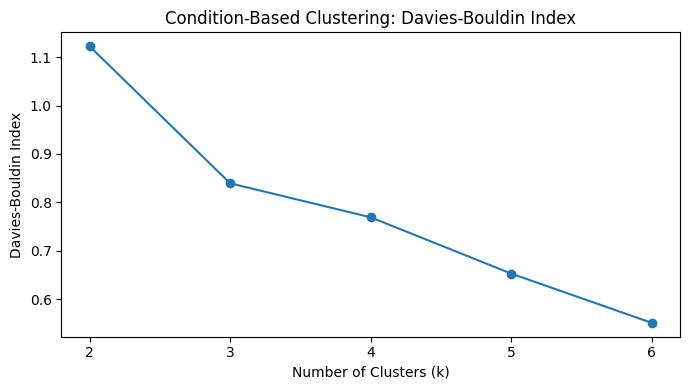

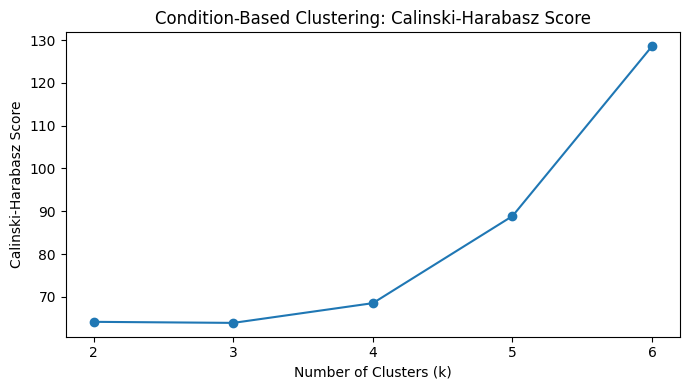

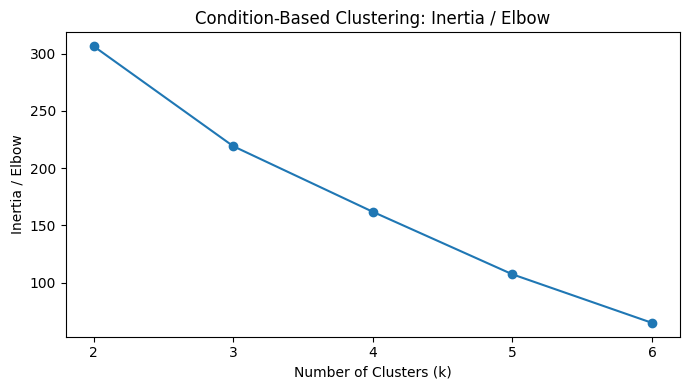

In [11]:
plot_clustering_metrics(condition_eval, "Condition-Based Clustering")

## Pemilihan Jumlah Cluster untuk Eksperimen A

Metrik dapat memberikan gambaran jumlah cluster yang baik secara matematis. Namun untuk kebutuhan lomba data analyst, cluster yang terlalu banyak bisa sulit dijelaskan.

Pada eksperimen ini, `k = 4` dipilih karena lebih mudah diterjemahkan menjadi persona intervensi:

1. Stable / low indicator.
2. Single or mixed issue.
3. Multi-issue silent struggle.
4. Reached support.

Jika kamu ingin eksplorasi lebih detail, nilai `best_k_condition` boleh diubah berdasarkan hasil metrik.

In [12]:
best_k_condition = 4

kmeans_condition = KMeans(
    n_clusters=best_k_condition,
    random_state=42,
    n_init=10
)

df["cluster_condition"] = kmeans_condition.fit_predict(X_condition_processed)

df[[
    "depression", "anxiety", "panic_attack", "treatment",
    "issue_count", "support_status", "risk", "cluster_condition"
]].head()

,depression,anxiety,panic_attack,treatment,issue_count,support_status,risk,cluster_condition
0,1,0,1,0,2,Silent Struggle,High Risk,2
1,0,1,0,0,1,Silent Struggle,Medium Risk,1
2,1,1,1,0,3,Silent Struggle,High Risk,0
3,1,0,0,0,1,Silent Struggle,Medium Risk,1
4,0,0,0,0,0,No Reported Issue,Low Risk,1


In [13]:
condition_cluster_profile = (
    df
    .groupby("cluster_condition")
    .agg(
        total_students=("cluster_condition", "count"),
        avg_issue_count=("issue_count", "mean"),
        depression_rate=("depression", "mean"),
        anxiety_rate=("anxiety", "mean"),
        panic_attack_rate=("panic_attack", "mean"),
        treatment_rate=("treatment", "mean"),
        silent_struggle_rate=("support_status", lambda x: (x == "Silent Struggle").mean()),
        high_risk_rate=("risk", lambda x: (x == "High Risk").mean())
    )
    .reset_index()
)

rate_cols = [
    "depression_rate", "anxiety_rate", "panic_attack_rate",
    "treatment_rate", "silent_struggle_rate", "high_risk_rate"
]

condition_cluster_profile[rate_cols] = condition_cluster_profile[rate_cols] * 100

condition_cluster_profile

,cluster_condition,total_students,avg_issue_count,depression_rate,anxiety_rate,panic_attack_rate,treatment_rate,silent_struggle_rate,high_risk_rate
0,0,18,2.500000,83.333333,100.0,66.666667,0.0,100.000000,100.000000
1,1,60,0.383333,16.666667,21.666667,0.0,0.0,38.333333,0.000000
2,2,17,1.235294,23.529412,0.0,100.0,0.0,100.000000,23.529412
3,3,6,2.166667,100.0,50.0,66.666667,100.0,0.000000,0.000000


In [14]:
def assign_condition_persona(row):
    if row["treatment_rate"] >= 50:
        return "Reached Support Persona"
    elif row["avg_issue_count"] >= 2:
        return "Multi-Issue Silent Struggle Persona"
    elif row["avg_issue_count"] >= 1:
        return "Single/Mixed-Issue Silent Struggle Persona"
    else:
        return "Stable / Low Indicator Persona"


condition_cluster_profile["persona"] = condition_cluster_profile.apply(assign_condition_persona, axis=1)

condition_cluster_profile = condition_cluster_profile[
    [
        "cluster_condition", "persona", "total_students", "avg_issue_count",
        "depression_rate", "anxiety_rate", "panic_attack_rate",
        "treatment_rate", "silent_struggle_rate", "high_risk_rate"
    ]
]

condition_cluster_profile

,cluster_condition,persona,total_students,avg_issue_count,depression_rate,anxiety_rate,panic_attack_rate,treatment_rate,silent_struggle_rate,high_risk_rate
0,0,Multi-Issue Silent Struggle Persona,18,2.500000,83.333333,100.0,66.666667,0.0,100.000000,100.000000
1,1,Stable / Low Indicator Persona,60,0.383333,16.666667,21.666667,0.0,0.0,38.333333,0.000000
2,2,Single/Mixed-Issue Silent Struggle Persona,17,1.235294,23.529412,0.0,100.0,0.0,100.000000,23.529412
3,3,Reached Support Persona,6,2.166667,100.0,50.0,66.666667,100.0,0.000000,0.000000


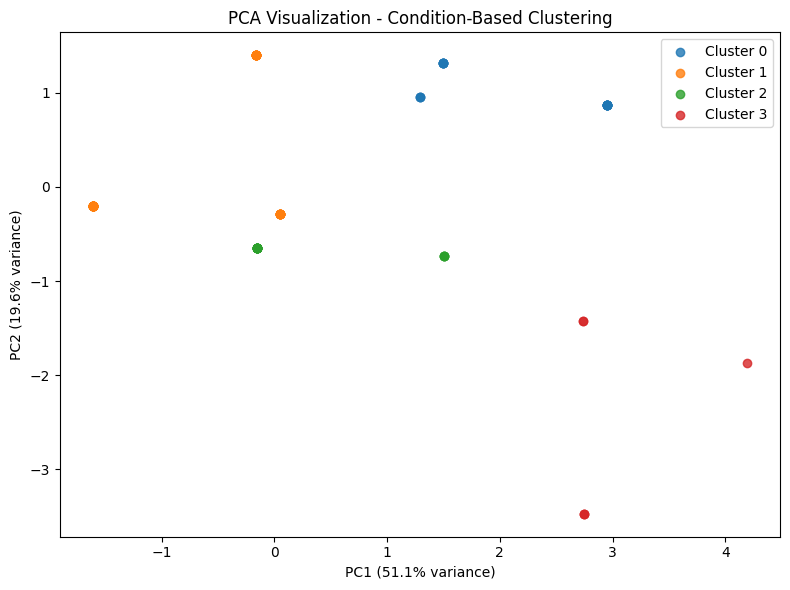

Total variance explained by PC1 + PC2: 70.7%


In [15]:
plot_pca_clusters(
    X_condition_processed,
    df["cluster_condition"],
    "PCA Visualization - Condition-Based Clustering"
)

In [16]:
condition_risk_crosstab = pd.crosstab(
    df["cluster_condition"],
    df["risk"],
    normalize="index"
) * 100

condition_risk_crosstab = condition_risk_crosstab.round(1)
condition_risk_crosstab

risk,Low Risk,Medium Risk,High Risk
cluster_condition,,,
0,0.0,0.0,100.0
1,61.7,38.3,0.0
2,0.0,76.5,23.5
3,100.0,0.0,0.0


### Interpretasi Eksperimen A

Clustering berbasis kondisi mental health membantu membentuk persona yang mudah dipahami.

Bagian paling penting dari eksperimen ini adalah melihat apakah ada cluster yang didominasi oleh:

- `High Risk`,
- `Medium Risk`,
- atau mahasiswa yang sudah `Reached Support`.

Jika satu cluster memiliki `silent_struggle_rate` dan `high_risk_rate` yang tinggi, maka cluster tersebut dapat menjadi prioritas utama dalam rancangan intervensi kampus.

Namun, eksperimen ini harus dibaca sebagai **persona berbasis kondisi**, bukan sebagai prediksi otomatis. Alasannya, fitur yang digunakan memang langsung berasal dari indikator mental health.

# Eksperimen B — Clustering Berdasarkan Profil Mahasiswa

Eksperimen kedua lebih aman untuk analisis karena cluster dibuat tanpa menggunakan kolom gejala mental health.

Fitur yang digunakan:

- `gender`
- `age`
- `course`
- `year`
- `cgpa`
- `marital_status`

Setelah cluster terbentuk, barulah kita bandingkan distribusi:

- `risk`
- `support_status`
- `issue_count`
- depression/anxiety/panic attack

Dengan cara ini, kita bisa menjawab pertanyaan:

> Apakah ada kelompok profil mahasiswa tertentu yang cenderung memiliki proporsi risk lebih tinggi?

In [17]:
profile_features = [
    "gender",
    "age",
    "course",
    "year",
    "cgpa",
    "marital_status"
]

categorical_cols = [
    "gender",
    "course",
    "year",
    "cgpa",
    "marital_status"
]

numeric_cols = ["age"]

preprocessor_profile = ColumnTransformer(
    transformers=[
        ("cat", make_ohe(), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

X_profile = df[profile_features].copy()
X_profile_processed = preprocessor_profile.fit_transform(X_profile)

profile_eval = evaluate_kmeans(X_profile_processed, k_range=range(2, 7))

profile_eval

,k,silhouette_score,davies_bouldin_index,calinski_harabasz_score,inertia
0,2,0.228397,1.697340,31.885109,293.815769
1,3,0.167891,1.921711,23.823961,261.367705
2,4,0.165121,1.804818,19.494907,242.333893
3,5,0.150009,2.046442,17.429252,225.026824
4,6,0.150416,1.956824,15.607150,213.264177


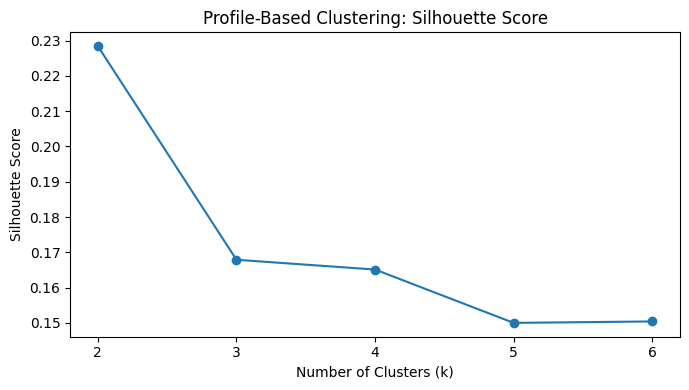

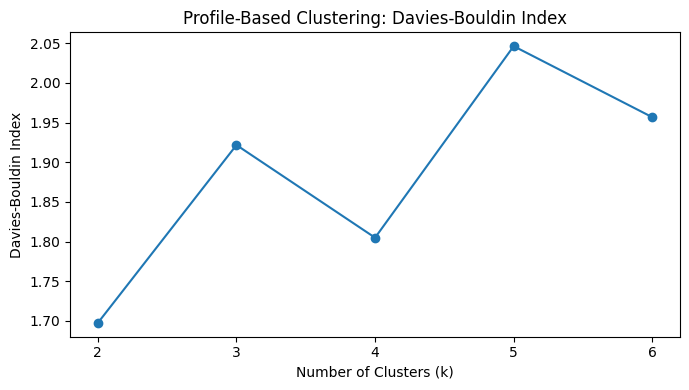

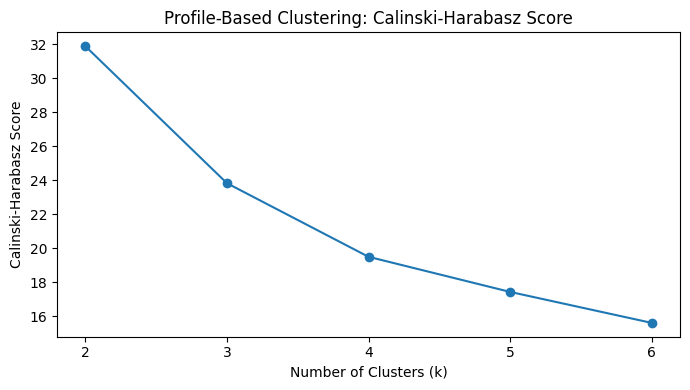

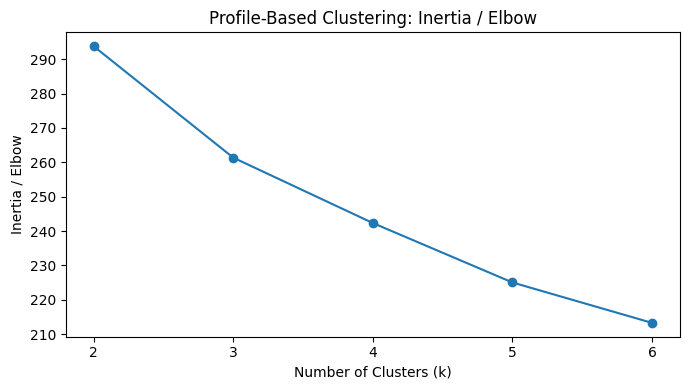

In [18]:
plot_clustering_metrics(profile_eval, "Profile-Based Clustering")

## Pemilihan Jumlah Cluster untuk Eksperimen B

Untuk eksperimen berbasis profil, hasil metrik biasanya tidak sekuat eksperimen berbasis kondisi mental health. Hal ini wajar karena fitur profil seperti course, gender, year, dan CGPA tidak selalu membentuk pola geometris yang sangat jelas.

Pada notebook ini, `k = 3` dipilih agar cluster tetap mudah dibaca:

1. Cluster profil 0
2. Cluster profil 1
3. Cluster profil 2

Fokusnya bukan mencari cluster paling sempurna, tetapi melihat apakah ada perbedaan proporsi risiko antar kelompok profil.

In [19]:
best_k_profile = 3

kmeans_profile = KMeans(
    n_clusters=best_k_profile,
    random_state=42,
    n_init=10
)

df["cluster_profile"] = kmeans_profile.fit_predict(to_dense(X_profile_processed))

df[profile_features + ["risk", "support_status", "issue_count", "cluster_profile"]].head()

,gender,age,course,year,cgpa,marital_status,risk,support_status,issue_count,cluster_profile
0,Female,18,Engineering,Year 1,3.00 - 3.49,0,High Risk,Silent Struggle,2,0
1,Male,21,Islamic Education,Year 2,3.00 - 3.49,0,Medium Risk,Silent Struggle,1,0
2,Male,19,BIT,Year 1,3.00 - 3.49,0,High Risk,Silent Struggle,3,0
3,Female,22,Laws,Year 3,3.00 - 3.49,1,Medium Risk,Silent Struggle,1,2
4,Male,23,Mathematics,Year 4,3.00 - 3.49,0,Low Risk,No Reported Issue,0,2


In [20]:
profile_cluster_summary = (
    df
    .groupby("cluster_profile")
    .agg(
        total_students=("cluster_profile", "count"),
        avg_age=("age", "mean"),
        avg_issue_count=("issue_count", "mean"),
        depression_rate=("depression", "mean"),
        anxiety_rate=("anxiety", "mean"),
        panic_attack_rate=("panic_attack", "mean"),
        treatment_rate=("treatment", "mean"),
        silent_struggle_rate=("support_status", lambda x: (x == "Silent Struggle").mean()),
        high_risk_rate=("risk", lambda x: (x == "High Risk").mean())
    )
    .reset_index()
)

rate_cols = [
    "depression_rate", "anxiety_rate", "panic_attack_rate",
    "treatment_rate", "silent_struggle_rate", "high_risk_rate"
]

profile_cluster_summary[rate_cols] = profile_cluster_summary[rate_cols] * 100

profile_cluster_summary.round(2)

,cluster_profile,total_students,avg_age,avg_issue_count,depression_rate,anxiety_rate,panic_attack_rate,treatment_rate,silent_struggle_rate,high_risk_rate
0,0,33,18.85,1.03,45.45,33.33,24.24,0.0,63.64,30.30
1,1,30,18.50,1.07,26.67,43.33,36.67,10.0,56.67,20.00
2,2,38,23.55,0.95,31.58,26.32,36.84,7.89,52.63,15.79


In [21]:
profile_risk_crosstab = pd.crosstab(
    df["cluster_profile"],
    df["risk"],
    normalize="index"
) * 100

profile_risk_crosstab = profile_risk_crosstab.round(1)
profile_risk_crosstab

risk,Low Risk,Medium Risk,High Risk
cluster_profile,,,
0,36.4,33.3,30.3
1,43.3,36.7,20.0
2,47.4,36.8,15.8


In [22]:
profile_support_crosstab = pd.crosstab(
    df["cluster_profile"],
    df["support_status"],
    normalize="index"
) * 100

profile_support_crosstab = profile_support_crosstab.round(1)
profile_support_crosstab

support_status,No Reported Issue,Reached Support,Silent Struggle
cluster_profile,,,
0,36.4,0.0,63.6
1,33.3,10.0,56.7
2,39.5,7.9,52.6


## Profil Dominan per Cluster

Bagian ini membantu memahami isi tiap cluster dari sisi karakteristik mahasiswa.

Karena banyak fitur kategorikal, kita tampilkan kategori dominan pada tiap cluster.

In [23]:
def dominant_category(series):
    vc = series.value_counts(normalize=True)
    top_label = vc.index[0]
    top_pct = vc.iloc[0] * 100
    return f"{top_label} ({top_pct:.1f}%)"


dominant_profile = (
    df
    .groupby("cluster_profile")
    .agg(
        total_students=("cluster_profile", "count"),
        dominant_gender=("gender", dominant_category),
        dominant_year=("year", dominant_category),
        dominant_cgpa=("cgpa", dominant_category),
        dominant_course=("course", dominant_category),
        dominant_marital_status=("marital_status", dominant_category),
        avg_age=("age", "mean")
    )
    .reset_index()
)

dominant_profile["avg_age"] = dominant_profile["avg_age"].round(1)

dominant_profile

,cluster_profile,total_students,dominant_gender,dominant_year,dominant_cgpa,dominant_course,dominant_marital_status,avg_age
0,0,33,Female (63.6%),Year 2 (36.4%),3.00 - 3.49 (87.9%),Engineering (18.2%),0 (84.8%),18.8
1,1,30,Female (83.3%),Year 1 (66.7%),3.50 - 4.00 (93.3%),BCS (30.0%),0 (90.0%),18.5
2,2,38,Female (76.3%),Year 3 (31.6%),3.50 - 4.00 (52.6%),Engineering (15.8%),0 (78.9%),23.6


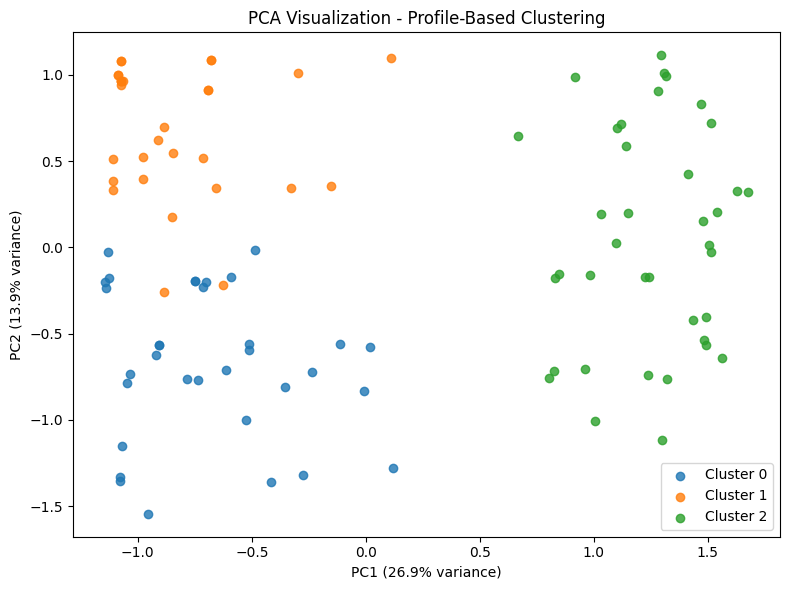

Total variance explained by PC1 + PC2: 40.7%


In [24]:
plot_pca_clusters(
    X_profile_processed,
    df["cluster_profile"],
    "PCA Visualization - Profile-Based Clustering"
)

### Interpretasi Eksperimen B

Eksperimen B lebih cocok untuk menjawab pertanyaan berbasis profil:

> Kelompok profil mahasiswa seperti apa yang memiliki proporsi risiko lebih tinggi?

Jika ada cluster profil dengan `High Risk` atau `Silent Struggle` lebih tinggi, cluster itu dapat dijadikan dasar segmentasi program.

Contoh interpretasi yang bisa digunakan:

- Jika sebuah cluster didominasi mahasiswa tahun awal dan memiliki silent struggle rate tinggi, maka kampus bisa memperkuat program adaptasi mahasiswa baru.
- Jika sebuah cluster didominasi mahasiswa tahun tengah dan memiliki high risk rate lebih tinggi, maka kampus bisa membuat program stress management, akademik, dan career anxiety support.
- Jika sebuah cluster memiliki treatment rate rendah tetapi issue count tinggi, maka perlu kanal bantuan yang lebih mudah, anonim, dan tidak menimbulkan stigma.

Catatan: karena dataset kecil, hasil cluster tidak boleh dianggap sebagai generalisasi final. Hasil ini sebaiknya dibaca sebagai sinyal awal untuk membantu desain solusi.

# 6. Visualisasi Perbandingan Cluster dan Risk

Bagian ini membuat visual yang lebih mudah dipakai untuk presentasi.

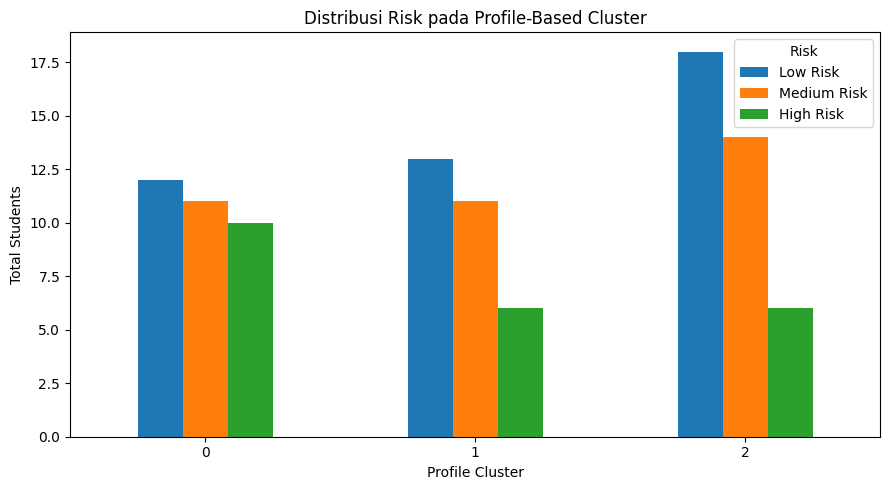

In [25]:
cluster_risk_count = pd.crosstab(
    df["cluster_profile"],
    df["risk"]
).reindex(columns=["Low Risk", "Medium Risk", "High Risk"])

cluster_risk_count.plot(kind="bar", figsize=(9, 5))

plt.title("Distribusi Risk pada Profile-Based Cluster")
plt.xlabel("Profile Cluster")
plt.ylabel("Total Students")
plt.xticks(rotation=0)
plt.legend(title="Risk")
plt.tight_layout()
plt.show()

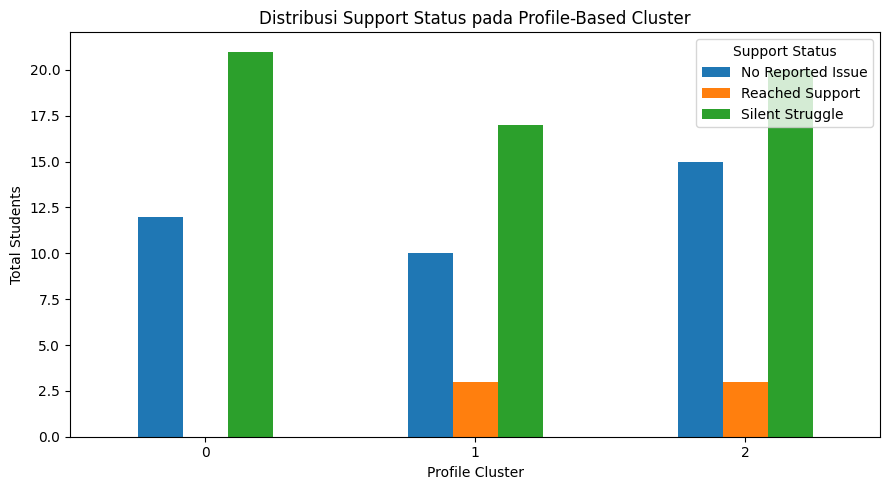

In [26]:
cluster_support_count = pd.crosstab(
    df["cluster_profile"],
    df["support_status"]
)

cluster_support_count.plot(kind="bar", figsize=(9, 5))

plt.title("Distribusi Support Status pada Profile-Based Cluster")
plt.xlabel("Profile Cluster")
plt.ylabel("Total Students")
plt.xticks(rotation=0)
plt.legend(title="Support Status")
plt.tight_layout()
plt.show()

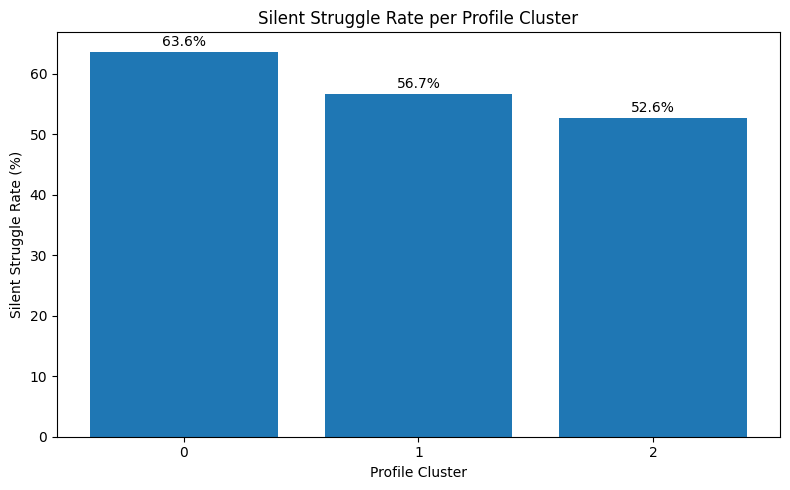

In [27]:
plt.figure(figsize=(8, 5))
plt.bar(
    profile_cluster_summary["cluster_profile"].astype(str),
    profile_cluster_summary["silent_struggle_rate"]
)

plt.title("Silent Struggle Rate per Profile Cluster")
plt.xlabel("Profile Cluster")
plt.ylabel("Silent Struggle Rate (%)")

for i, row in profile_cluster_summary.iterrows():
    plt.text(
        i,
        row["silent_struggle_rate"] + 1,
        f"{row['silent_struggle_rate']:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

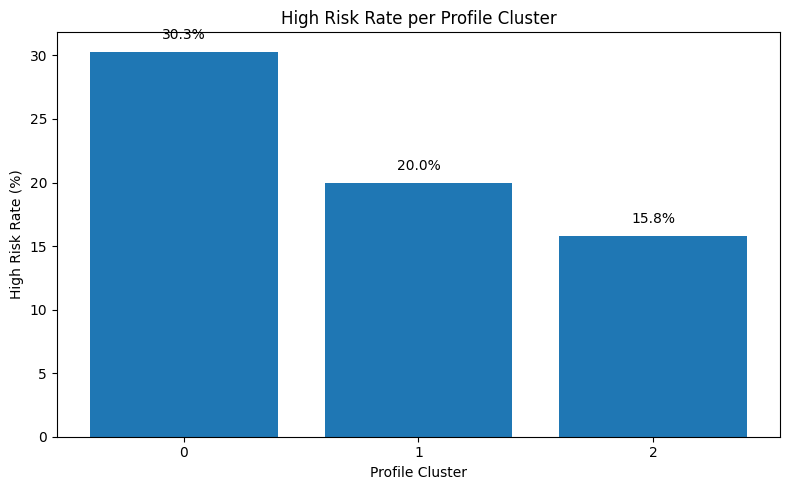

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(
    profile_cluster_summary["cluster_profile"].astype(str),
    profile_cluster_summary["high_risk_rate"]
)

plt.title("High Risk Rate per Profile Cluster")
plt.xlabel("Profile Cluster")
plt.ylabel("High Risk Rate (%)")

for i, row in profile_cluster_summary.iterrows():
    plt.text(
        i,
        row["high_risk_rate"] + 1,
        f"{row['high_risk_rate']:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

# 7. Rekomendasi Berdasarkan Cluster

Dari hasil clustering, solusi tidak hanya diarahkan berdasarkan label `risk`, tetapi juga berdasarkan persona cluster.

## Hubungan KPI, Risk, dan Clustering

- KPI menunjukkan adanya masalah utama, yaitu **support gap**.
- Label `risk` mengubah masalah tersebut menjadi prioritas intervensi.
- Clustering membantu memahami kelompok mahasiswa yang memiliki pola serupa.
- Hasil cluster dapat digunakan untuk membuat program yang lebih sesuai dengan kebutuhan tiap kelompok.

## Contoh rancangan intervensi

| Kelompok | Sinyal Data | Rekomendasi |
|---|---|---|
| Low Risk / Stable | Issue rendah, tidak banyak indikator | Program preventif, edukasi umum, mental health awareness |
| Medium Risk | 1 indikator dan belum mencari bantuan | Self-assessment anonim, kampanye anti-stigma, edukasi layanan konseling |
| High Risk | Minimal 2 indikator dan belum mencari bantuan | Outreach proaktif, referral konselor, check-in berkala |
| Reached Support | Sudah mencari bantuan | Evaluasi kualitas layanan, follow-up non-invasif |

## Implementasi pada Silent Struggle Dashboard

Dashboard dapat memiliki fitur:

1. **KPI Monitoring**
   - At-risk rate
   - Silent struggle rate
   - High risk rate
   - Support reach rate

2. **Risk Priority Mapping**
   - Low Risk
   - Medium Risk
   - High Risk

3. **Cluster Persona View**
   - Persona berdasarkan kondisi mental health
   - Persona berdasarkan profil mahasiswa

4. **Recommended Action**
   - Setiap cluster diberi rekomendasi program yang berbeda.

5. **Privacy Layer**
   - Data ditampilkan secara agregat.
   - Tidak digunakan untuk diagnosis.
   - Tidak menampilkan identitas individu.
   - Akses data sensitif dibatasi untuk pihak yang berwenang.

# 8. Export Hasil

Bagian ini mengekspor hasil clustering agar bisa dipakai untuk laporan, dashboard, atau analisis lanjutan.

In [29]:
OUTPUT_DIR = Path("clustering_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df.to_csv(OUTPUT_DIR / "student_mental_health_with_clusters.csv", index=False)
condition_cluster_profile.to_csv(OUTPUT_DIR / "condition_cluster_profile.csv", index=False)
profile_cluster_summary.to_csv(OUTPUT_DIR / "profile_cluster_summary.csv", index=False)
dominant_profile.to_csv(OUTPUT_DIR / "dominant_profile_cluster.csv", index=False)

print("Export selesai.")
print("Folder output:", OUTPUT_DIR.resolve())

Export selesai.
Folder output: C:\Users\MSI SWORD 16\Kuliah\Lomba\TEKRA\clustering_outputs


# 9. Kesimpulan Final

Clustering dapat digunakan sebagai analisis tambahan yang kuat untuk project ini.

Model klasifikasi `risk` tetap berguna sebagai sistem prioritas, tetapi akurasi sekitar 70% menunjukkan bahwa dataset masih terbatas untuk prediksi supervised yang benar-benar kuat.

Karena itu, clustering digunakan untuk memperkaya insight:

- menemukan persona mahasiswa,
- memahami distribusi risk pada tiap cluster,
- dan merancang solusi yang lebih spesifik.

Kesimpulan yang dapat digunakan dalam laporan:

> Karena dataset berukuran kecil dan model klasifikasi belum menghasilkan performa yang sangat tinggi, analisis clustering digunakan sebagai pendekatan tambahan untuk menemukan pola kelompok mahasiswa. Hasil clustering tidak dimaknai sebagai diagnosis, tetapi sebagai dasar segmentasi intervensi. Dengan menggabungkan KPI, label risk, dan cluster persona, kampus dapat menyusun strategi dukungan kesehatan mental yang lebih terarah, berbasis prioritas, dan tetap memperhatikan privasi mahasiswa.